In [1]:
import subprocess, sys
 
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
 
install("torch-geometric")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00


In [2]:
import os
print(os.listdir("/kaggle/input/datasets/senbati/goad-for-training"))
print(os.listdir("/kaggle/input/models/senbati/gcn/pytorch/default/1"))

['zoom.csv', 'heterodata.pt', 'training_examples.json', 'forest_graph.json']
['best_model.pt']


In [3]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import GCNConv
 
# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
 
# Kaggle input paths
HETERODATA_PATH  = Path("/kaggle/input/datasets/senbati/goad-for-training/heterodata.pt")
EXAMPLES_PATH    = Path("/kaggle/input/datasets/senbati/goad-for-training/training_examples.json")
CHECKPOINT_PATH  = Path("/kaggle/working/best_model.pt")

DATASET_PATH   = Path("/kaggle/input/datasets/senbati/goad-for-training")
CHECKPOINT_HGT = Path("/kaggle/working/HGT.pt")
CHECKPOINT_GCN = Path("/kaggle/input/models/senbati/gcn/pytorch/default/1/best_model.pt")  # upload if available

Device: cuda


In [4]:
data = torch.load(
    DATASET_PATH / "heterodata.pt",
    map_location=DEVICE,
    weights_only=False,
)

# 1. HGTConv Metadata (Dynamically pulled from our true HeteroData)
NODE_TYPES = data.node_types
EDGE_TYPES = data.edge_types
metadata = (NODE_TYPES, EDGE_TYPES)

print("HeteroData loaded (True HGT Format):")
for nt in NODE_TYPES:
    print(f"  {nt:<15}: {data[nt].num_nodes} nodes, {data[nt].x.shape[1]} features")
print(f"\n  Edge types : {len(EDGE_TYPES)}")
for src, rel, dst in EDGE_TYPES:
    n = data[src, rel, dst].edge_index.shape[1]
    print(f"    {rel:<20} ({src} -> {dst}): {n} edges")

# 2. Load training examples (Now contains true heterogeneous coordinates)
with open(DATASET_PATH / "training_examples.json") as f:
    all_examples = json.load(f)

constrained   = [e for e in all_examples if e["mode"] == "constrained"]
unconstrained = [e for e in all_examples if e["mode"] == "unconstrained"]
print(f"\nTraining examples: {len(all_examples)} "
      f"({len(constrained)} constrained + {len(unconstrained)} unconstrained)")

# 3. Node features & Edge indices dictionary (Required for HGT)
x_dict = {nt: data[nt].x.to(DEVICE) for nt in NODE_TYPES}
edge_index_dict = {et: data[et].edge_index.to(DEVICE) for et in EDGE_TYPES}

# 4. Build flat edge_index and offsets for legacy lookups/debugging
NODE_ORDER = ["users", "computers", "groups", "domains",
              "gpos", "ous", "containers", "cas", "certtemplates"]

type_offsets = {}
curr_offset = 0
for nt in NODE_ORDER:
    type_offsets[nt] = curr_offset
    if nt in data.node_types:
        curr_offset += data[nt].num_nodes

edge_tensors_flat = []
for (src_t, rel, dst_t), ei in data.edge_index_dict.items():
    if src_t not in type_offsets or dst_t not in type_offsets: continue
    ei_shifted = ei.clone().to(DEVICE)
    ei_shifted[0] += type_offsets[src_t]
    ei_shifted[1] += type_offsets[dst_t]
    edge_tensors_flat.append(ei_shifted)

edge_index_flat = torch.unique(torch.cat(edge_tensors_flat, dim=1), dim=1)
print(f"\nFlat edge_index for neighbor lookup: {edge_index_flat.shape[1]} edges")

# 5. idx → name lookup (using the correct forest_graph.json)
forest = json.load(open(DATASET_PATH / "forest_graph.json"))
idx_to_name = {}

for nt in NODE_ORDER:
    local_idx = 0
    for obj in forest.get(nt, []) or []:
        oid = (obj.get("ObjectIdentifier") or "").upper()
        if not oid: continue
        name = (obj.get("Properties", {}).get("name") or "unknown")
        global_idx = type_offsets[nt] + local_idx
        idx_to_name[global_idx] = name
        local_idx += 1

    # Add the null sentinel for Unconstrained mode
    if nt == "users" and "users" in data.node_types:
        if local_idx < data["users"].num_nodes:
            sentinel_idx = type_offsets["users"] + local_idx
            idx_to_name[sentinel_idx] = "<null>"

print(f"Name lookup built: {len(idx_to_name)} entries")

HeteroData loaded (True HGT Format):
  users          : 48 nodes, 14 features
  computers      : 5 nodes, 14 features
  groups         : 166 nodes, 14 features
  domains        : 3 nodes, 14 features
  gpos           : 8 nodes, 14 features
  ous            : 12 nodes, 14 features
  containers     : 66 nodes, 14 features

  Edge types : 75
    owns                 (groups -> users): 44 edges
    genericall           (groups -> users): 86 edges
    addkeycredentiallink (groups -> users): 56 edges
    genericwrite         (groups -> users): 76 edges
    writeowner           (groups -> users): 76 edges
    allextendedrights    (groups -> users): 77 edges
    writedacl            (groups -> users): 76 edges
    allowedtodelegate    (users -> computers): 1 edges
    genericall           (users -> users): 7 edges
    forcechangepassword  (users -> users): 1 edges
    writedacl            (users -> users): 1 edges
    genericwrite         (users -> users): 3 edges
    readgmsapassword     (gro

In [5]:
from torch_geometric.nn import HGTConv, Linear
import torch.nn as nn
import torch.nn.functional as F

HIDDEN_DIM  = 64
NUM_HEADS   = 4    # attention heads in HGTConv
NUM_LAYERS  = 2
POLICY_DIM  = 32

# Enforce strict ordering to match inference.py global offsets
NODE_ORDER = ["users", "computers", "groups", "domains",
              "gpos", "ous", "containers", "cas", "certtemplates"]

class HGTEncoder(nn.Module):
    """
    Heterogeneous Graph Transformer encoder.
    """
    def __init__(self, in_channels: int, hidden_dim: int,
                 num_heads: int, num_layers: int, metadata: tuple):
        super().__init__()

        # input projection — one per node type
        self.input_proj = nn.ModuleDict({
            node_type: Linear(-1, hidden_dim)
            for node_type in metadata[0]
        })

        # HGTConv layers
        self.convs = nn.ModuleList([
            HGTConv(
                in_channels  = hidden_dim,
                out_channels = hidden_dim,
                metadata     = metadata,
                heads        = num_heads,
            )
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x_dict: dict,
                edge_index_dict: dict) -> torch.Tensor:
        
        # project all node types to hidden_dim
        h_dict = {}
        for node_type, x in x_dict.items():
            h_dict[node_type] = F.relu(self.input_proj[node_type](x))

        # message passing — type-aware attention at each layer
        for i, conv in enumerate(self.convs):
            h_dict = conv(h_dict, edge_index_dict)
            if i < len(self.convs) - 1:
                h_dict = {k: self.dropout(F.relu(v))
                          for k, v in h_dict.items()}

        # CRITICAL FIX: concatenate strictly using NODE_ORDER
        # This guarantees the flat output matrix perfectly aligns with inference.py IDs
        all_embeddings = torch.cat(
            [h_dict[nt] for nt in NODE_ORDER if nt in h_dict],
            dim=0
        )
        return all_embeddings   # [N × hidden_dim]


class PolicyHead(nn.Module):
    """Identical to GCN notebook."""
    def __init__(self, hidden_dim: int, policy_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, policy_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(policy_dim, 1),
        )

    def forward(self, current_emb: torch.Tensor,
                neighbor_embs: torch.Tensor) -> torch.Tensor:
        current_expanded = current_emb.unsqueeze(0).expand_as(neighbor_embs)
        interaction = current_expanded * neighbor_embs
        return self.mlp(interaction).squeeze(-1)


class HGTNavigator(nn.Module):
    """
    Full HGT model: HGTEncoder + PolicyHead.
    """
    def __init__(self, in_channels: int, hidden_dim: int,
                 num_heads: int, num_layers: int,
                 policy_dim: int, metadata: tuple):
        super().__init__()
        self.encoder     = HGTEncoder(in_channels, hidden_dim,
                                       num_heads, num_layers, metadata)
        self.policy_head = PolicyHead(hidden_dim, policy_dim)

    def encode(self, x_dict: dict,
               edge_index_dict: dict) -> torch.Tensor:
        return self.encoder(x_dict, edge_index_dict)

    def score(self, embeddings: torch.Tensor,
              current_idx: int,
              neighbor_idxs: list) -> torch.Tensor:
        current_emb   = embeddings[current_idx]
        neighbor_embs = embeddings[
            torch.tensor(neighbor_idxs, device=embeddings.device)
        ]
        return self.policy_head(current_emb, neighbor_embs)


# Note: x_dict and edge_index_dict were correctly built in the PREVIOUS cell!
# We just need to grab the input feature dimension dynamically.
feature_dim = x_dict["users"].shape[1] if "users" in x_dict else 14

# instantiate model
model = HGTNavigator(
    in_channels = feature_dim,
    hidden_dim  = HIDDEN_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    policy_dim  = POLICY_DIM,
    metadata    = metadata,
).to(DEVICE)


# trigger lazy init with one forward pass
with torch.no_grad():
    _ = model.encode(x_dict, edge_index_dict)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"HGT model parameters: {total_params:,}")
print("Model initialised successfully")

HGT model parameters: 549,607
Model initialised successfully


In [6]:
def get_neighbors(edge_index: torch.Tensor, node_idx: int, n_nodes: int) -> list:
    """
    STRICTLY DIRECTED: Emulates BloodHound pathfinding.
    An attacker at node_idx can only traverse edges where they are the SOURCE.
    """
    src, dst = edge_index
    
    # We only care where the current node is the source of the privilege
    mask_out = (src == node_idx)
    
    # Extract only the valid destinations
    neighbors = dst[mask_out].unique().tolist()
    
    return [n for n in neighbors if n != node_idx]


def compute_loss(model, embeddings, edge_index, example):
    current_idx  = example["current_idx"]
    next_hop_idx = example["next_hop_idx"]
    eff_weight   = example.get("eff_weight", 1.0)

    neighbors = get_neighbors(edge_index, current_idx, embeddings.shape[0])
    if not neighbors:
        return None
        
    # If target isn't a direct neighbor (e.g., skip-level traces), append it
    # so the cross entropy doesn't crash, but it will be heavily penalized
    if next_hop_idx not in neighbors:
        neighbors.append(next_hop_idx)

    label_pos = neighbors.index(next_hop_idx)
    label     = torch.tensor([label_pos], dtype=torch.long,
                               device=embeddings.device)
                               
    scores = model.score(embeddings, current_idx, neighbors).unsqueeze(0)
    loss   = F.cross_entropy(scores, label)
    return loss * eff_weight


def train_epoch(model, x_dict, edge_index_dict,
                edge_index_flat, examples, optimizer):
    model.train()
    optimizer.zero_grad()

    # HGT encodes using the heterogeneous dicts
    embeddings = model.encode(x_dict, edge_index_dict)

    # Initialize loss as a standard Python float to avoid GPU device mismatch
    total_loss  = 0.0
    valid_count = 0
    shuffled    = examples.copy()
    random.shuffle(shuffled)

    for ex in shuffled:
        # neighbor lookup uses flat edge_index (all types merged)
        loss = compute_loss(model, embeddings, edge_index_flat, ex)
        if loss is None:
            continue
            
        total_loss  = total_loss + loss
        valid_count += 1

    if valid_count == 0:
        return 0.0

    mean_loss = total_loss / valid_count
    mean_loss.backward()
    
    # Gradient clipping prevents exploding gradients in small datasets
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    return mean_loss.item()

Starting HGT training...
  Examples  : 52
  Epochs    : 500
  Heads     : 4
  Layers    : 2
----------------------------------------
Epoch    1  loss: 0.6467  best: 0.6467  lr: 0.00500
Epoch   50  loss: 0.0000  best: 0.0000  lr: 0.00500
Epoch  100  loss: 0.0000  best: 0.0000  lr: 0.00500
Epoch  150  loss: 0.0000  best: 0.0000  lr: 0.00250
Early stop at epoch 200

HGT training complete. Best loss: 0.0000
Checkpoint → /kaggle/working/HGT.pt


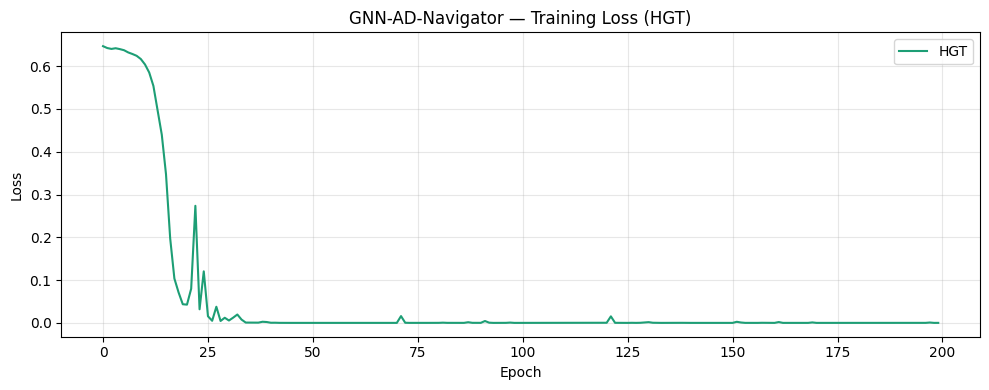

In [7]:
EPOCHS    = 500
LR        = 0.005
LOG_EVERY = 50

optimizer = torch.optim.Adam(model.parameters(),
                              lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=150, gamma=0.5
)

best_loss    = float("inf")
loss_history = []

print("Starting HGT training...")
print(f"  Examples  : {len(all_examples)}")
print(f"  Epochs    : {EPOCHS}")
print(f"  Heads     : {NUM_HEADS}")
print(f"  Layers    : {NUM_LAYERS}")
print("-" * 40)

PATIENCE      = 100
MIN_EPOCHS    = 200   # don't stop before this regardless of patience
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, x_dict, edge_index_dict,
                       edge_index_flat, all_examples, optimizer)  
    loss_history.append(loss)
    
    # Step the scheduler so the learning rate actually decays
    scheduler.step()
    
    if loss < best_loss - 1e-5:
        best_loss = loss
        patience_counter = 0
        
        # CRITICAL: Added metadata and num_features for inference.py compatibility
        torch.save({
            "epoch":        epoch,
            "model_state":  model.state_dict(),
            "loss":         loss,
            "architecture": "HGT",
            "hidden_dim":   HIDDEN_DIM,
            "num_heads":    NUM_HEADS,
            "num_layers":   NUM_LAYERS,
            "num_features": feature_dim,
            "metadata":     metadata
        }, CHECKPOINT_HGT)
    else:
        patience_counter += 1
    
    if epoch >= MIN_EPOCHS and patience_counter >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"Epoch {epoch:>4}  loss: {loss:.4f}  "
              f"best: {best_loss:.4f}  "
              f"lr: {scheduler.get_last_lr()[0]:.5f}")

print(f"\nHGT training complete. Best loss: {best_loss:.4f}")
print(f"Checkpoint → {CHECKPOINT_HGT}")

plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=1.5, color="#1D9E75", label="HGT")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("GNN-AD-Navigator — Training Loss (HGT)")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve_hgt.png", dpi=150)
plt.show()

In [8]:
def evaluate(model, feature_input, edge_input, edge_index_flat,
             examples, k=3):
    model.eval()
    with torch.no_grad():
        # Both models use .encode(), we just pass them their respective inputs
        embeddings = model.encode(feature_input, edge_input)

    hits_model = hits_random = 0
    mrr = 0.0
    total = 0

    for ex in examples:
        if ex["mode"] != "constrained":
            continue
        current_idx  = ex["current_idx"]
        next_hop_idx = ex["next_hop_idx"]

        # Use embeddings.shape[0] instead of the deleted X variable
        neighbors = get_neighbors(edge_index_flat, current_idx, embeddings.shape[0])
        if not neighbors:
            continue
        if next_hop_idx not in neighbors:
            neighbors.append(next_hop_idx)

        with torch.no_grad():
            scores = model.score(embeddings, current_idx, neighbors)
        ranked = [neighbors[i] for i in
                  torch.argsort(scores, descending=True).tolist()]

        if next_hop_idx in ranked[:k]:
            hits_model += 1
        if next_hop_idx in ranked:
            mrr += 1.0 / (ranked.index(next_hop_idx) + 1)
        if len(neighbors) <= k or next_hop_idx in random.sample(neighbors,k):
            hits_random += 1
        total += 1

    return {
        "precision_at_k":   hits_model  / max(total, 1),
        "random_precision": hits_random / max(total, 1),
        "mrr":              mrr         / max(total, 1),
        "total":            total,
        "k":                k,
    }


# 1. Load best HGT checkpoint
ckpt = torch.load(CHECKPOINT_HGT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded HGT checkpoint (epoch {ckpt['epoch']}, loss {ckpt['loss']:.4f})")

# Evaluate HGT
hgt_results = evaluate(model, x_dict, edge_index_dict, edge_index_flat,
                        all_examples, k=3)

print("\n" + "=" * 55)
print(f"{'METRIC':<30} {'HGT':>10} {'GCN':>10}")
print("=" * 55)

# 2. Try to load GCN results for comparison
gcn_p3 = gcn_mrr = "N/A"
try:
    from torch_geometric.nn import GCNConv
    class GCNEncoder(nn.Module):
        def __init__(self, in_c, hid):
            super().__init__()
            self.conv1 = GCNConv(in_c, hid)
            self.conv2 = GCNConv(hid, hid)
            self.bn1   = nn.BatchNorm1d(hid)
            self.bn2   = nn.BatchNorm1d(hid)
        def forward(self, x, ei):
            x = F.relu(self.bn1(self.conv1(x, ei)))
            x = F.dropout(x, 0.3, self.training)
            return F.relu(self.bn2(self.conv2(x, ei)))

    class GCNPolicyHead(nn.Module):
        def __init__(self, hid, pol):
            super().__init__()
            self.mlp = nn.Sequential(
                nn.Linear(hid, pol), nn.ReLU(),
                nn.Dropout(0.2), nn.Linear(pol, 1))
        def forward(self, cur, nbr):
            return self.mlp(cur.unsqueeze(0).expand_as(nbr)*nbr).squeeze(-1)

    class GCNNavigator(nn.Module):
        def __init__(self, in_c, hid, pol):
            super().__init__()
            self.encoder     = GCNEncoder(in_c, hid)
            self.policy_head = GCNPolicyHead(hid, pol)
        def encode(self, x, ei): return self.encoder(x, ei)
        def score(self, emb, cur, nbrs):
            return self.policy_head(emb[cur],
                   emb[torch.tensor(nbrs, device=emb.device)])

    # Dynamically flatten the features for the legacy GCN
    X_flat = torch.cat([x_dict[nt] for nt in NODE_ORDER if nt in x_dict], dim=0)

    gcn_model = GCNNavigator(X_flat.shape[1], HIDDEN_DIM, POLICY_DIM).to(DEVICE)
    gcn_ckpt  = torch.load(CHECKPOINT_GCN, map_location=DEVICE, weights_only=False)
    gcn_model.load_state_dict(gcn_ckpt["model_state"])
    gcn_model = gcn_model.to(DEVICE)
    gcn_model.eval()

    gcn_results = evaluate(
        gcn_model, X_flat, edge_index_flat, edge_index_flat,
        all_examples, k=3
    )
    gcn_p3  = f"{gcn_results['precision_at_k']:.3f}"
    gcn_mrr = f"{gcn_results['mrr']:.3f}"
except Exception as e:
    print(f"  (GCN comparison skipped: {e})")

print(f"  {'Precision@3':<28} {hgt_results['precision_at_k']:>10.3f} {gcn_p3:>10}")
print(f"  {'MRR':<28} {hgt_results['mrr']:>10.3f} {gcn_mrr:>10}")
print(f"  {'Precision@3 (random)':<28} {hgt_results['random_precision']:>10.3f}")
print(f"  {'Examples evaluated':<28} {hgt_results['total']:>10}")
print("=" * 55)

Loaded HGT checkpoint (epoch 45, loss 0.0000)

METRIC                                HGT        GCN
  Precision@3                       1.000      0.909
  MRR                               1.000      0.780
  Precision@3 (random)              1.000
  Examples evaluated                   22


In [9]:
import math

def beam_search(model, embeddings, edge_index, start_idx,
                target_idx, beam_width=3, max_depth=8):
    beam      = [(0.0, [start_idx])]
    completed = []

    for _ in range(max_depth):
        candidates = []
        for log_score, path in beam:
            current = path[-1]
            if current == target_idx:
                completed.append((log_score, path))
                continue
            neighbors = get_neighbors(edge_index, current,
                                      embeddings.shape[0])
            neighbors = [n for n in neighbors if n not in path]
            if not neighbors:
                continue
            with torch.no_grad():
                scores = model.score(embeddings, current, neighbors)
                probs  = F.softmax(scores, dim=0)
            for i, nb in enumerate(neighbors):
                ns = log_score + math.log(probs[i].item() + 1e-9)
                candidates.append((ns, path + [nb]))
                if nb == target_idx:
                    completed.append((ns, path + [nb]))

        if not candidates:
            break
        candidates.sort(key=lambda x: x[0], reverse=True)
        beam = candidates[:beam_width]
        if len(completed) >= beam_width:
            break

    result = completed if completed else beam
    result.sort(key=lambda x: x[0], reverse=True)
    return result[:beam_width]

# Build a quick lookup dictionary for edge names using the global flat IDs
edge_name_map = {}
for (src_t, rel, dst_t), ei in data.edge_index_dict.items():
    if src_t not in type_offsets or dst_t not in type_offsets: 
        continue
    # Shift local indices to global to match the path output
    src_indices = ei[0] + type_offsets[src_t]
    dst_indices = ei[1] + type_offsets[dst_t]
    for s, d in zip(src_indices.tolist(), dst_indices.tolist()):
        # If multiple edges exist between two nodes, just grab the first one
        if (s, d) not in edge_name_map:
            edge_name_map[(s, d)] = rel

def resolve_path_with_edges(path, idx_to_name, edge_name_map):
    steps = []
    for i in range(len(path) - 1):
        src = path[i]
        dst = path[i+1]
        src_name = idx_to_name.get(src, f"idx_{src}")
        
        # 1. Check for a standard forward edge
        if (src, dst) in edge_name_map:
            rel = edge_name_map[(src, dst)]
            steps.append(f"{src_name} \n    -[{rel}]-> ")
            
        # 2. Check if the model traversed the edge backwards
        elif (dst, src) in edge_name_map:
            rel = edge_name_map[(dst, src)]
            steps.append(f"{src_name} \n    -[inv_{rel}]-> ")
            
        # 3. Fallback (should be extremely rare now)
        else:
            steps.append(f"{src_name} \n    -[???]-> ")
            
    # Add the final target node
    steps.append(idx_to_name.get(path[-1], f"idx_{path[-1]}"))
    return "".join(steps)


# demo with objective nodes from training data
model.eval()
with torch.no_grad():
    embeddings = model.encode(x_dict, edge_index_dict)

obj_examples = [e for e in all_examples if e["mode"] == "constrained"]

print("\nBeam search demo — HGT")
print("=" * 75)

if len(obj_examples) >= 2:
    ex_start  = obj_examples[0]
    ex_target = obj_examples[-1]
    
    start_idx  = type_offsets[ex_start["current_type"]] + ex_start["current_local"]
    target_idx = type_offsets[ex_target["next_hop_type"]] + ex_target["next_hop_local"]

    paths = beam_search(model, embeddings, edge_index_flat,
                        start_idx, target_idx,
                        beam_width=3, max_depth=15)

    s_name = idx_to_name.get(start_idx,  f"idx_{start_idx}")
    t_name = idx_to_name.get(target_idx, f"idx_{target_idx}")
    print(f"Start  : {s_name}")
    print(f"Target : {t_name}")
    print(f"\nTop-{len(paths)} paths:")

    for rank, (score, path) in enumerate(paths, 1):
        prob = math.exp(score)
        named = resolve_path_with_edges(path, idx_to_name, edge_name_map)
        print(f"\n[ Path {rank} ]  Confidence: {prob:.4f}  Steps: {len(path)-1}")
        print(f"  {named}")

print("\n" + "=" * 75)
print("Outputs saved to /kaggle/working/")
print(f"  {CHECKPOINT_HGT.name}  → HGT weights and metadata")
print("  loss_curve_hgt.png → training loss")


Beam search demo — HGT
Start  : castelblack.north.sevenkingdoms.local
Target : kingslanding.sevenkingdoms.local

Top-3 paths:

[ Path 1 ]  Confidence: 0.2858  Steps: 3
  castelblack.north.sevenkingdoms.local 
    -[allowedtodelegate]-> winterfell.north.sevenkingdoms.local 
    -[memberof]-> enterprise domain controllers@sevenkingdoms.local 
    -[memberof]-> windows authorization access group@sevenkingdoms.local

[ Path 2 ]  Confidence: 0.2515  Steps: 3
  castelblack.north.sevenkingdoms.local 
    -[allowedtodelegate]-> winterfell.north.sevenkingdoms.local 
    -[memberof]-> enterprise domain controllers@sevenkingdoms.local 
    -[writeowner]-> microsoftdns@sevenkingdoms.local

[ Path 3 ]  Confidence: 0.2444  Steps: 3
  castelblack.north.sevenkingdoms.local 
    -[allowedtodelegate]-> winterfell.north.sevenkingdoms.local 
    -[memberof]-> enterprise domain controllers@sevenkingdoms.local 
    -[genericall]-> keys@sevenkingdoms.local

Outputs saved to /kaggle/working/
  HGT.pt  → HGT 